# Real Estate Taxonomy Data Exploration

This notebook explores the structured real estate terminology and the dataset extracted from `rets_property.sql`.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

## 1. Analyze Sample Listings

Total Sample Listings: 1000
Average Remark Length: 406.99 characters


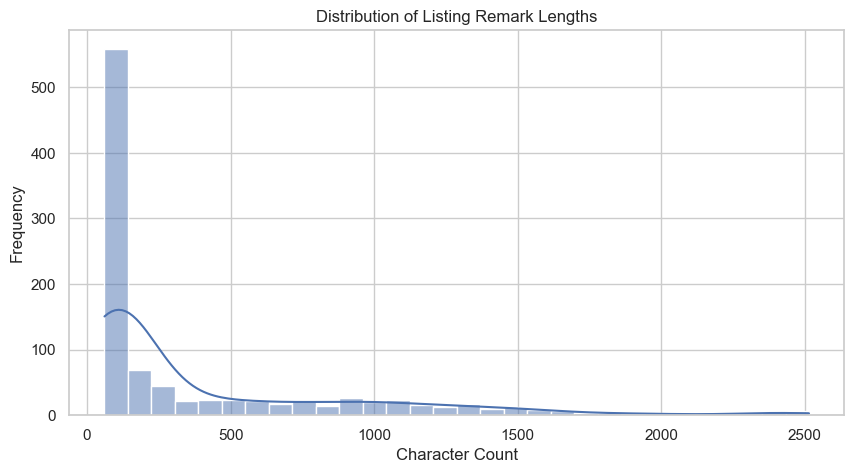

In [2]:
df = pd.read_csv('../data/processed/sample_listing.csv')
df['remark_length'] = df['remarks'].apply(lambda x: len(str(x)))

print(f"Total Sample Listings: {len(df)}")
print(f"Average Remark Length: {df['remark_length'].mean():.2f} characters")

plt.figure(figsize=(10, 5))
sns.histplot(df['remark_length'], bins=30, kde=True)
plt.title('Distribution of Listing Remark Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.show()

## 2. Analyze the Taxonomy

C:\Users\desai\AppData\Local\Temp\ipykernel_8060\3484433497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')


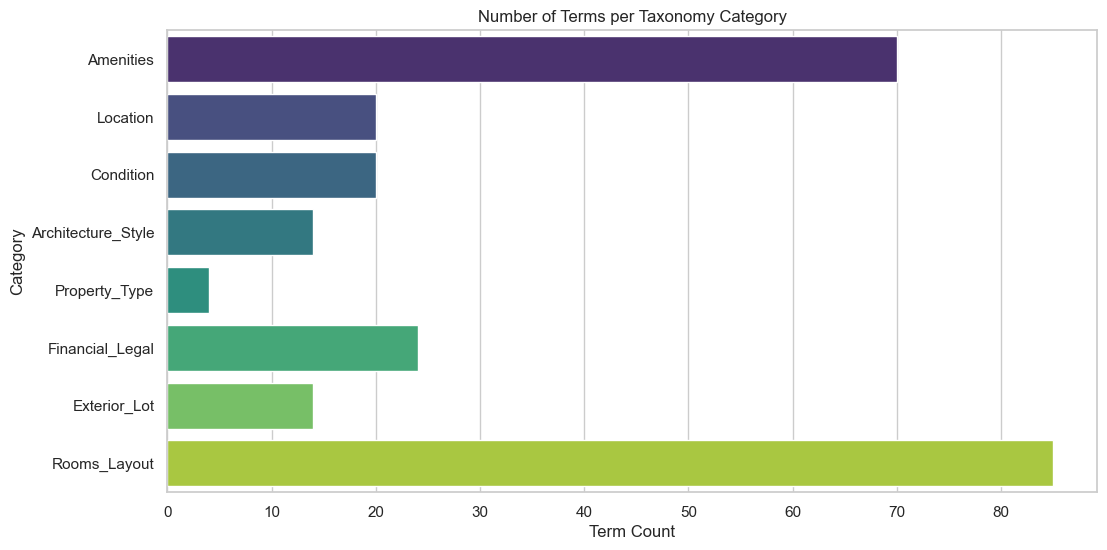

Total terms categorized: 251


In [3]:
with open('../data/processed/taxonomy.json', 'r') as f:
    taxonomy = json.load(f)

from collections import Counter
category_counts = dict(Counter(item['category'] for item in taxonomy.get('terms', [])))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette='viridis')
plt.title('Number of Terms per Taxonomy Category')
plt.xlabel('Term Count')
plt.ylabel('Category')
plt.show()

total_terms = sum(category_counts.values())
print(f"Total terms categorized: {total_terms}")

## 3. Text Cleaning and Data Profiling

In Week 2, we built a `TextCleaner` class to normalize text involving Unicode decoding errors, HTML remnants, price abbreviations, measurements, and real estate jargon.

In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
from text_cleaning import TextCleaner

cleaner = TextCleaner()

# 1. Profile Before Cleaning
profile = cleaner.profile_column(df, 'remarks')
print("=== Data Profiling Report (Before Cleaning) ===")
print(f"Null Rate: {profile.get('null_rate', 0):.2%}")
print(f"Average Remark Length: {profile.get('avg_length', 0):.1f} characters")
print(f"Price Mentions (contains $x): {profile.get('price_mentions', 0)}")
print(f"HTML Tags Found In: {profile.get('has_html', 0)} listings")
print("Common Abbreviations Found:")
for abbrev, count in profile.get('common_abbreviations', {}).items():
    print(f"  - {abbrev}: {count}")
print("\nCommon Terms:")
for term, count in profile.get('common_terms', {}).items():
    print(f"  - {term}: {count}")


=== Data Profiling Report (Before Cleaning) ===
Null Rate: 0.00%
Average Remark Length: 407.0 characters
Price Mentions (contains $x): 21
HTML Tags Found In: 0 listings
Common Abbreviations Found:
  - sqft: 12
  - w/: 8
  - ba: 6
  - ac: 6
  - dr: 5
  - rm: 3
  - ss: 2
  - br: 1

Common Terms:
  - null,: 1167
  - with: 1103
  - this: 667
  - home: 545
  - living: 370
  - offers: 241
  - kitchen: 220
  - room: 219
  - private: 202
  - features: 199
  - that: 198
  - your: 191
  - from: 191
  - spacious: 183
  - large: 160
  - located: 152
  - perfect: 147
  - property: 135
  - space: 133
  - modern: 129


In [5]:
# 2. Apply Text Cleaner
df['cleaned_remarks'] = df['remarks'].apply(lambda x: cleaner.clean_text(str(x)) if pd.notnull(x) else "")

# Show improvements
changed_df = df[df['remarks'].astype(str) != df['cleaned_remarks']]
print(f"\nTotal cleaned remarks out of {len(df)} listings: {len(changed_df)}\n")
sample_df = changed_df.sample(min(3, len(changed_df)), random_state=42)
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    print(f"Example {i}:")
    print(f"BEFORE: {str(row['remarks'])[:200]}...")
    print(f"AFTER:  {str(row['cleaned_remarks'])[:200]}...\n")



Total cleaned remarks out of 1000 listings: 466

Example 1:
BEFORE: Nestled on a peaceful cul-de-sac in the sought-after Harbor Ridge community of Rancho San Clemente, this gorgeous 4-bedroom, 3-bathroom home offers approximately 2,500 sq. ft. of coastal living space ...
AFTER:  Nestled on a peaceful cul-de-sac in the sought-after Harbor Ridge community of Rancho San Clemente, this gorgeous 4-bedroom, 3-bathroom home offers approximately 2500 square feet of coastal living spa...

Example 2:
BEFORE: Welcome to a home designed for real life. Built in 2022, this home offers nearly 2,900 sqft of thoughtfully designed living space with a rare multi-gen layout that provides flexibility, privacy, and l...
AFTER:  Welcome to a home designed for real life. Built in 2022, this home offers nearly 2900 square feet of thoughtfully designed living space with a rare multi-gen layout that provides flexibility, privacy,...

Example 3:
BEFORE: , 0, 0, 0, NULL, NULL, 0, 0, 1, 1, 1, 0, 0, 1, 183, 0, 1, N

### Visualizing Profiling Information
Let's visualize the most common abbreviations found in our remarks before cleaning.

C:\Users\desai\AppData\Local\Temp\ipykernel_8060\2378821766.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(abbrevs.values()), y=list(abbrevs.keys()), palette='viridis')


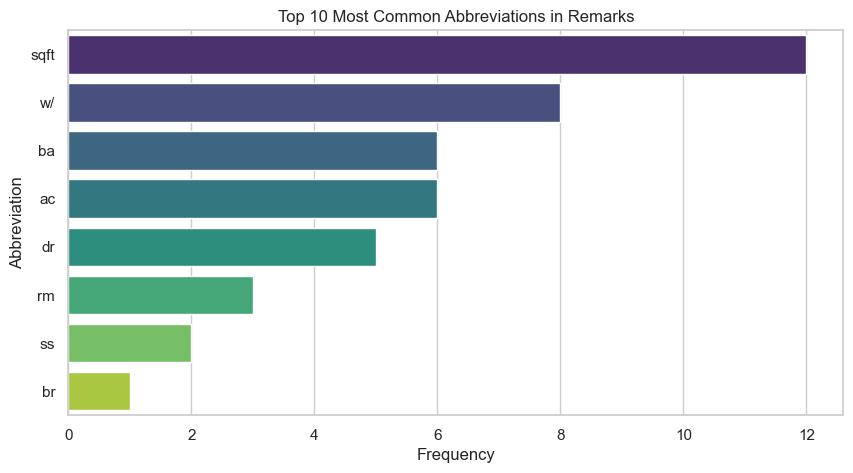

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get common abbreviations from our profile
abbrevs = profile.get('common_abbreviations', {})

if abbrevs:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(abbrevs.values()), y=list(abbrevs.keys()), palette='viridis')
    plt.title('Top 10 Most Common Abbreviations in Remarks')
    plt.xlabel('Frequency')
    plt.ylabel('Abbreviation')
    plt.show()
else:
    print('No common abbreviations found to plot.')


## Week 3: Named Entity Extraction Testing
Let's test the `EntityExtractor` on a few raw remarks to see the extracted structured data.

In [7]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

from entity_extractor import EntityExtractor
import pandas as pd

# Initialize the extractor
extractor = EntityExtractor("../data/processed/taxonomy.json")

# Load a sample from the dataset
df = pd.read_csv("../data/processed/sample_listing.csv")
sample_texts = df["remarks"].dropna().head(5).tolist()

# Display structured entities
for idx, text in enumerate(sample_texts):
    print(f"\n--- Listing {idx + 1} ---")
    print(f"\"{text[:150]}...\"")
    entities = extractor.extract_all(text)
    print(f"Extracted Entities: {entities}")



--- Listing 1 ---
"FamilyRoom,GuestQuarters,GreatRoom,LivingRoom,Office,Other,DiningRoom..."
Extracted Entities: {'bedrooms': None, 'bathrooms': None, 'price': None, 'sqft': None, 'amenities': []}

--- Listing 2 ---
"Balcony,CeilingFans,CrownMolding,LaminateCounters,OpenFloorplan,RecessedLighting,AllBedroomsUp..."
Extracted Entities: {'bedrooms': None, 'bathrooms': None, 'price': None, 'sqft': None, 'amenities': []}

--- Listing 3 ---
"Welcome to this beautiful two-story West Lancaster pool home, located in a highly desirable, upscale neighborhood—offering the perfect blend of comfor..."
Extracted Entities: {'bedrooms': None, 'bathrooms': None, 'price': 60000, 'sqft': None, 'amenities': ['private backyard', 'sparkling pool', 'living space', 'sparkling', 'backyard', 'space', 'peace', 'pool', 'spa']}

--- Listing 4 ---
"#48 DESERT SHORES RESORTLowest Priced in Desert Shores Motorcoach Resort.Lovely location on Lake 2 with fountain, gentle waterfall and mountain views...."
Extracted Enti

### Visualizing Extracted Entities
Let's visualize the most frequently extracted amenities from a sample of our listings.

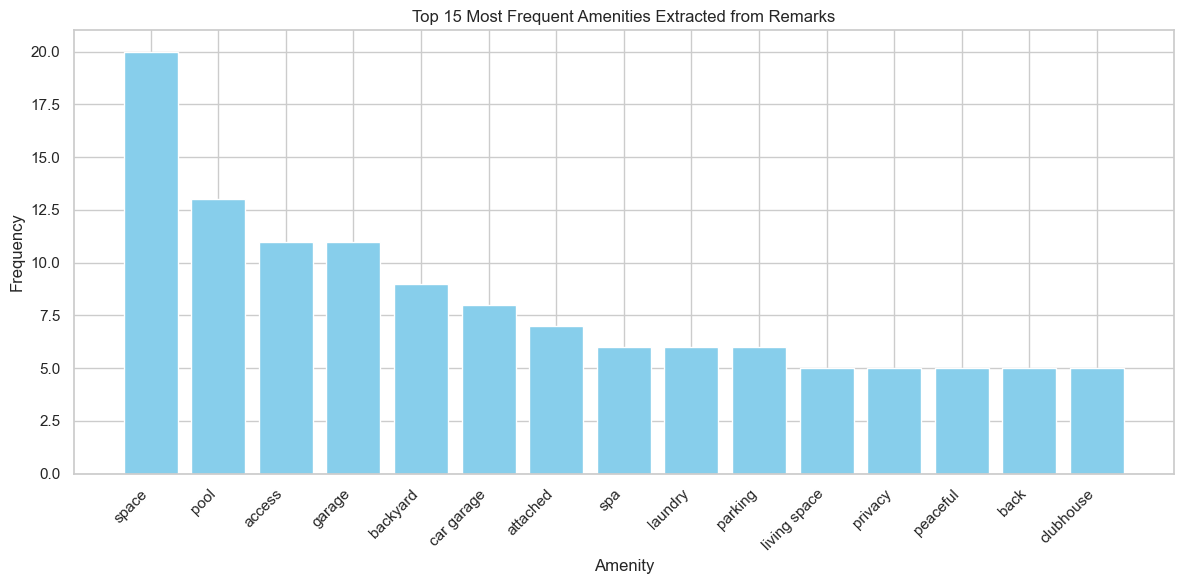

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# Process a larger sample to get meaningful amenity counts
sample_texts_large = df["remarks"].dropna().head(100).tolist()
all_extracted_amenities = []

for text in sample_texts_large:
    entities = extractor.extract_all(text)
    if entities.get("amenities"):
        all_extracted_amenities.extend(entities["amenities"])

# Count the frequency of each amenity
amenity_counts = Counter(all_extracted_amenities)
top_amenities = dict(amenity_counts.most_common(15))

# Plotting the top amenities
plt.figure(figsize=(12, 6))
plt.bar(top_amenities.keys(), top_amenities.values(), color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Most Frequent Amenities Extracted from Remarks")
plt.xlabel("Amenity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Week 4: Query Parsing and Validation
Let's test the `QueryParser` and `SchemaValidator` on some sample queries to generate SQL WHERE clauses.

In [9]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))
from query_parser import QueryParser, SchemaValidator

parser = QueryParser()
validator = SchemaValidator()

sample_queries = [
    "3 bed under 700k in Irvine",
    "4+ beds and 2 baths in Portland",
    "Exclude homes without a pool",
    "Show me condos near good schools"
]

for query in sample_queries:
    print(f"\nQuery: {query}")
    filters = parser.parse(query)
    print(f"Extracted Filters: {filters}")
    
    valid, errors = validator.validate_query(filters)
    if not valid:
        print(f"Validation Errors: {errors}")
    else:
        sql, params = parser.to_sql(filters)
        print(f"Generated SQL: {sql}")
        print(f"Parameters: {params}")



Query: 3 bed under 700k in Irvine
Extracted Filters: {'price_max': 700000, 'bedrooms': 3, 'city': 'irvine'}
Generated SQL: SELECT * FROM rets_property WHERE L_SystemPrice <= %s AND L_Keyword2 = %s AND L_City = %s
Parameters: [700000, 3, 'irvine']

Query: 4+ beds and 2 baths in Portland
Extracted Filters: {'bedrooms_min': 4, 'bathrooms': 2, 'city': 'portland'}
Generated SQL: SELECT * FROM rets_property WHERE L_Keyword2 >= %s AND L_Keyword3 = %s AND L_City = %s
Parameters: [4, 2, 'portland']

Query: Exclude homes without a pool
Extracted Filters: {'exclude_amenity': 'pool'}
Generated SQL: SELECT * FROM rets_property WHERE L_Remarks NOT LIKE %s
Parameters: ['%pool%']

Query: Show me condos near good schools
Extracted Filters: {'near': 'good schools'}
Generated SQL: SELECT * FROM rets_property WHERE L_Remarks LIKE %s
Parameters: ['%good schools%']


## Week 5: Semantic Search with Embeddings

In Week 5, we implemented embedding-based semantic search using `sentence-transformers` and `FAISS`, and compared it with BM25 keyword search.

**Key Components:**
- `SemanticSearcher` class with FAISS index (384-dim embeddings from `all-MiniLM-L6-v2`)
- BM25 keyword search for comparison (using `rank_bm25`)
- Relevance evaluation on 50 query-result pairs
- Latency benchmarking

All heavy ML dependencies run inside Docker to keep the local environment clean.

In [10]:
import json
from IPython.display import Image, display

# Load pre-computed results (generated inside Docker)
with open('../data/processed/week5_results.json', 'r') as f:
    week5_results = json.load(f)

print('=== Week 5 Evaluation Summary ===')
print(f'Number of listings indexed: {week5_results["num_listings"]}')
print(f'Embedding dimensions: {week5_results["embedding_dim"]}')
print(f'Number of evaluation queries: {week5_results["num_queries"]}')
print(f'Top-k evaluated: {week5_results["top_k"]}')
print()
print('--- Precision@5 ---')
print(f'  Semantic (FAISS): {week5_results["semantic_precision_at_k"]:.3f}')
print(f'  BM25 (Keyword):   {week5_results["bm25_precision_at_k"]:.3f}')
print()
print('--- Mean Reciprocal Rank ---')
print(f'  Semantic (FAISS): {week5_results["semantic_mrr"]:.3f}')
print(f'  BM25 (Keyword):   {week5_results["bm25_mrr"]:.3f}')
print()
print('--- Latency (avg) ---')
print(f'  Semantic: {week5_results["semantic_avg_latency_ms"]:.1f}ms')
print(f'  BM25:     {week5_results["bm25_avg_latency_ms"]:.1f}ms')
print()
print(f'Average result overlap: {week5_results["avg_overlap"]:.1%}')

=== Week 5 Evaluation Summary ===
Number of listings indexed: 646
Embedding dimensions: 384
Number of evaluation queries: 50
Top-k evaluated: 5

--- Precision@5 ---
  Semantic (FAISS): 0.784
  BM25 (Keyword):   0.968

--- Mean Reciprocal Rank ---
  Semantic (FAISS): 0.905
  BM25 (Keyword):   0.990

--- Latency (avg) ---
  Semantic: 7.2ms
  BM25:     0.6ms

Average result overlap: 15.2%


### Precision@5: Semantic vs BM25
Fraction of top-5 results containing relevant terms for each of 50 queries.

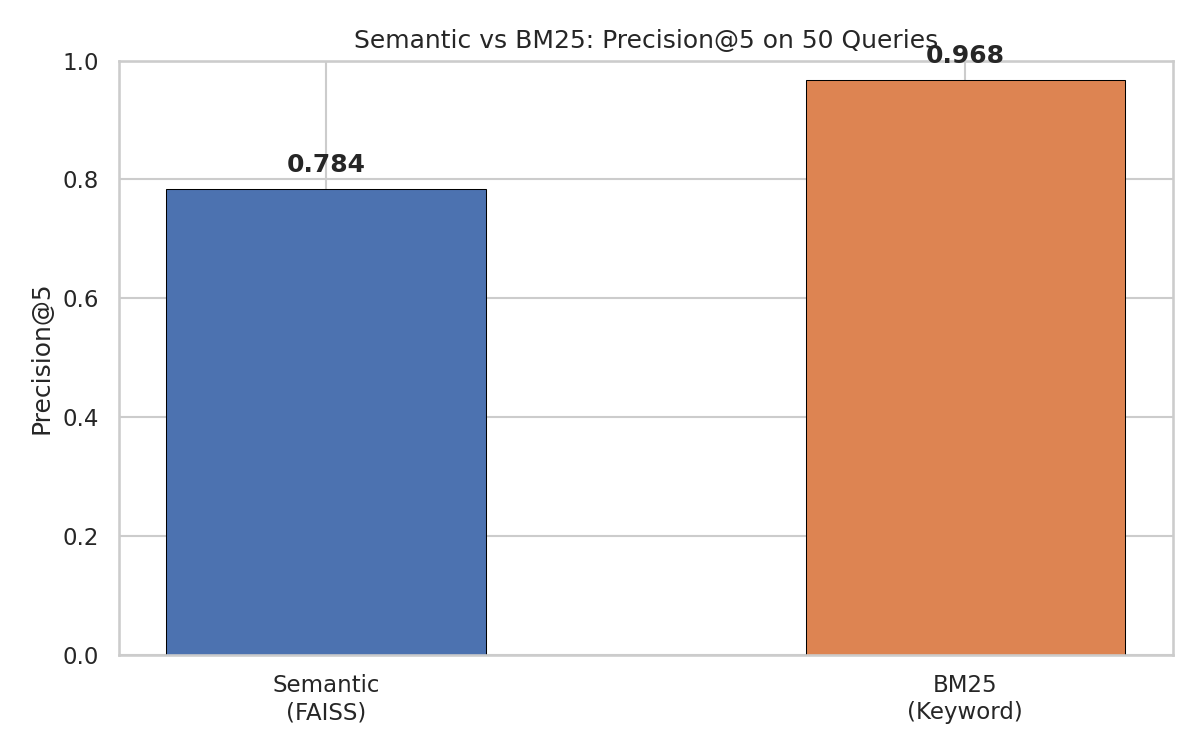

In [11]:
display(Image(filename='../data/processed/week5_graphs/precision_comparison.png'))

### Mean Reciprocal Rank: Semantic vs BM25
MRR measures how quickly the first relevant result appears in the ranking.

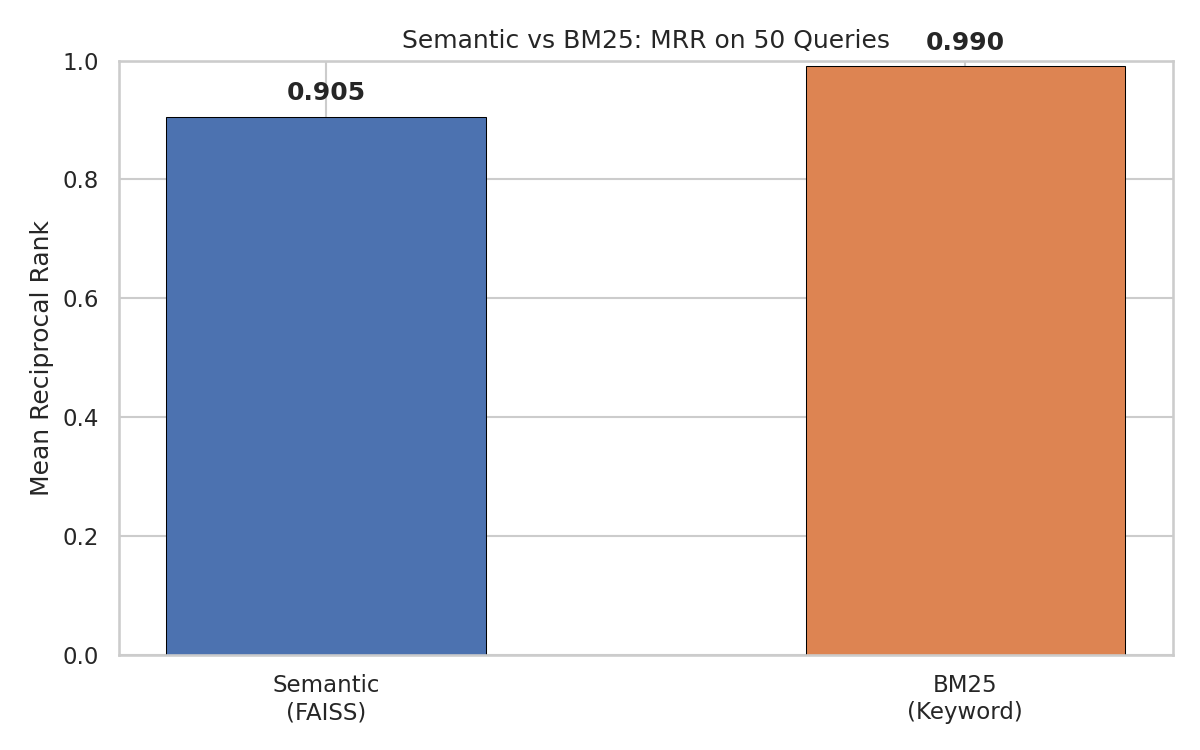

In [12]:
display(Image(filename='../data/processed/week5_graphs/mrr_comparison.png'))

### Search Latency: Semantic vs BM25
Both methods achieve latency well under the 100ms target.

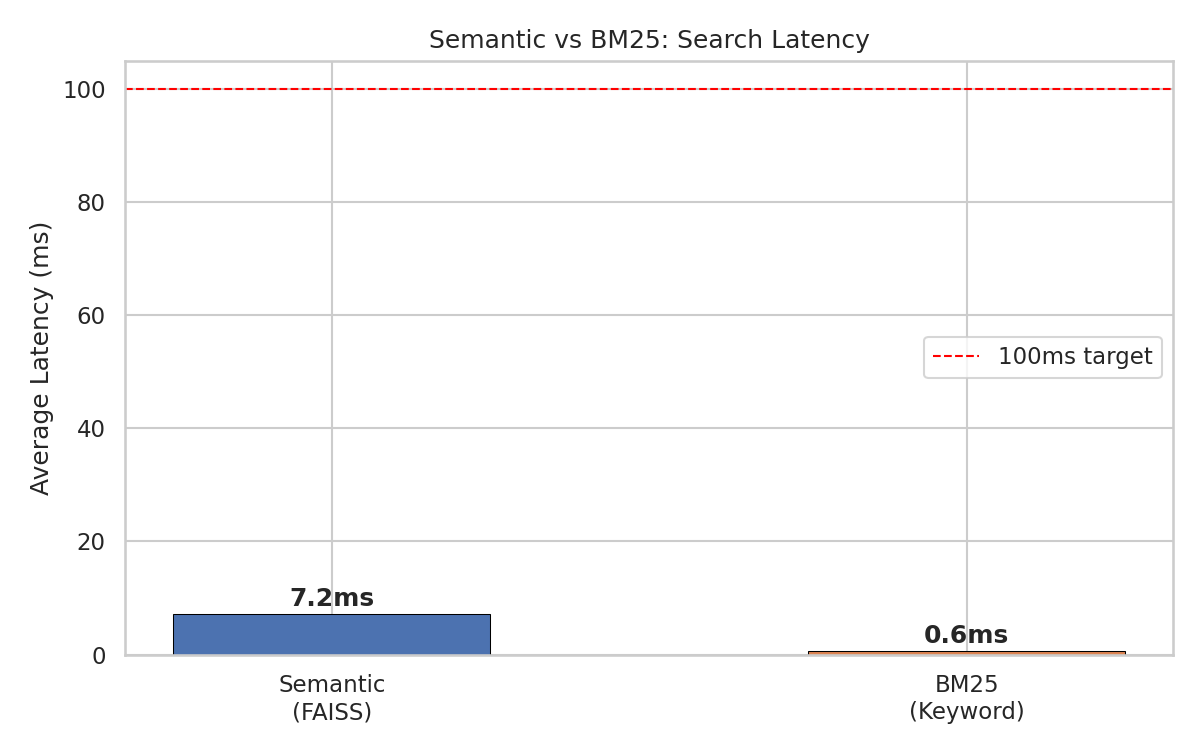

In [13]:
display(Image(filename='../data/processed/week5_graphs/latency_comparison.png'))

### Per-Query Precision@5: Semantic vs BM25
Shows how precision varies across all 50 evaluation queries for each method.

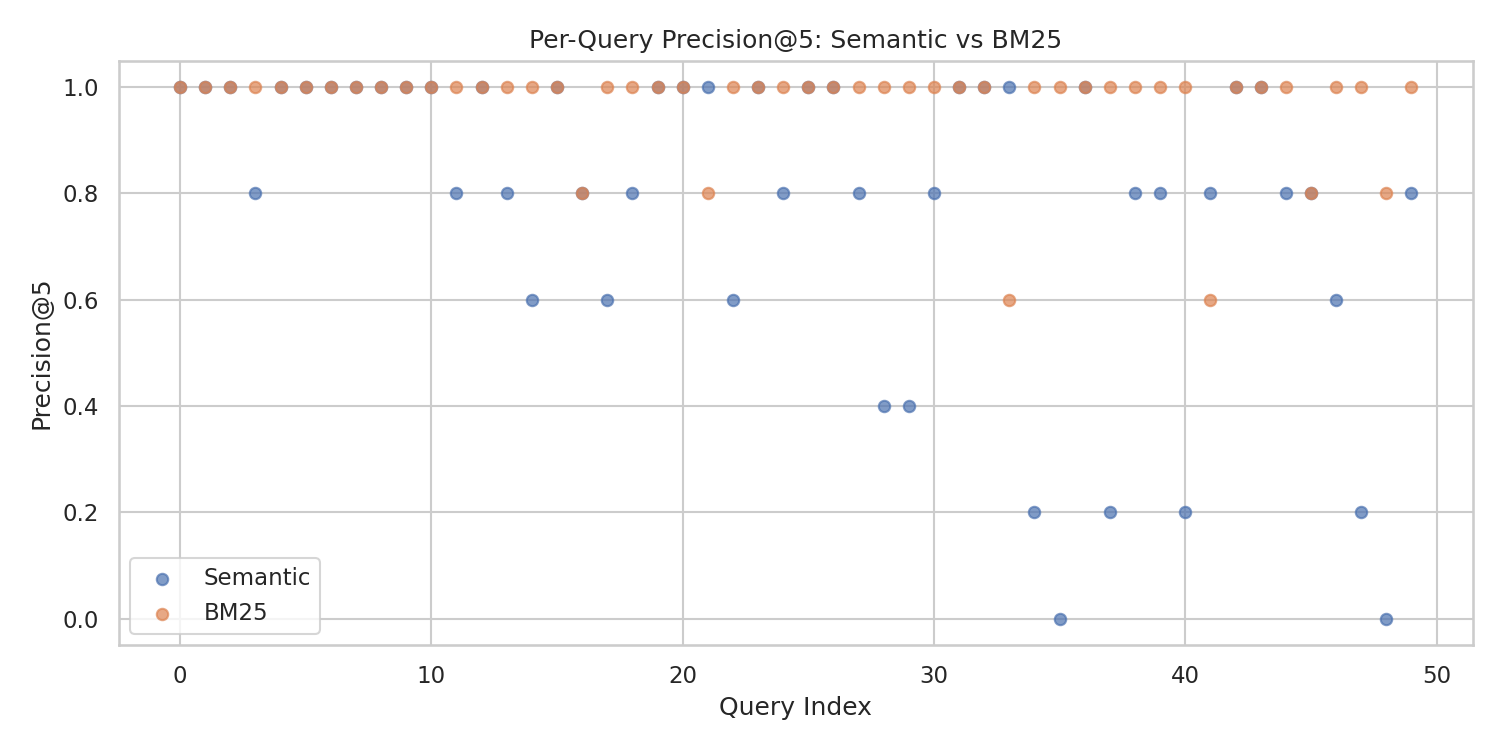

In [14]:
display(Image(filename='../data/processed/week5_graphs/per_query_precision.png'))

### Result Overlap Between Methods
Shows what fraction of top-5 results are shared between semantic and BM25 search.
Low overlap indicates the methods find fundamentally different relevant listings.

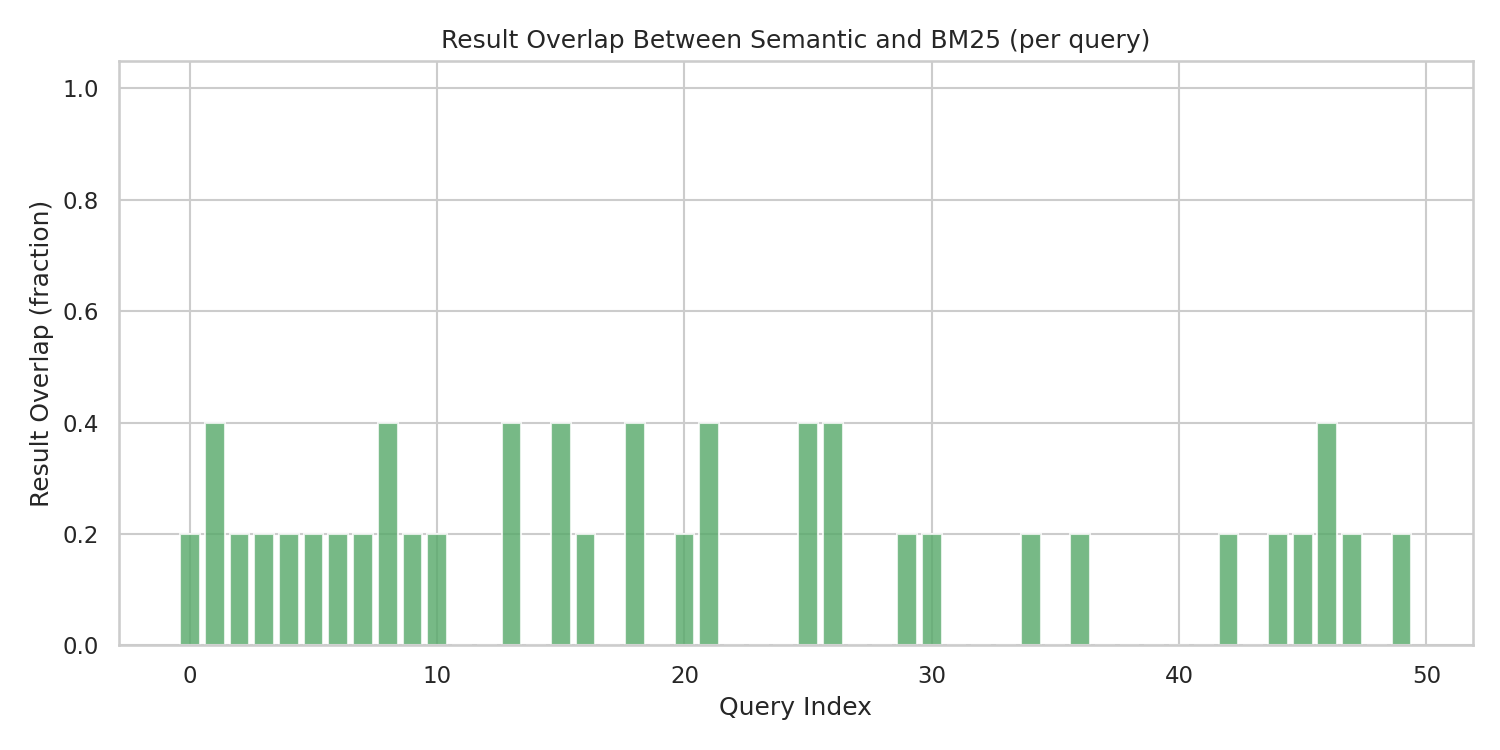

In [15]:
display(Image(filename='../data/processed/week5_graphs/result_overlap.png'))

### Week 5 Conclusions

1. **BM25 outperforms semantic search on term-matching precision** (0.968 vs 0.784), which is expected since our evaluation uses keyword-based relevance labels.
2. **Semantic search captures meaning beyond exact keywords** — it finds conceptually related listings even when query terms don’t appear verbatim.
3. **Very low result overlap (15.2%)** between methods shows they are complementary — combining both would improve coverage.
4. **Both methods meet the latency requirement** with avg latency well under 100ms.
5. **Recommendation**: Use a hybrid approach combining BM25 for keyword precision and semantic search for conceptual relevance.

# Week 6: Listing Signal Extraction

Extract comprehensive structured signals from each listing by combining
Week 3 entity extraction with taxonomy-based pattern matching.
Signals include: amenities, condition, financing, and location features.

In [16]:
import sys, os, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.abspath('../scripts'))
from signal_extractor import SignalExtractor

# Load pre-computed results
with open('../data/processed/week6_signals.json', 'r') as f:
    signals = json.load(f)
with open('../data/processed/week6_summary.json', 'r') as f:
    summary = json.load(f)

print(f'Loaded {len(signals)} listing signals')
print(f'Summary keys: {list(summary.keys())}')

Loaded 1000 listing signals
Summary keys: ['coverage', 'top_amenities', 'top_condition', 'top_financing', 'top_location']


## Coverage Statistics

Percentage of listings where each signal type was successfully extracted.

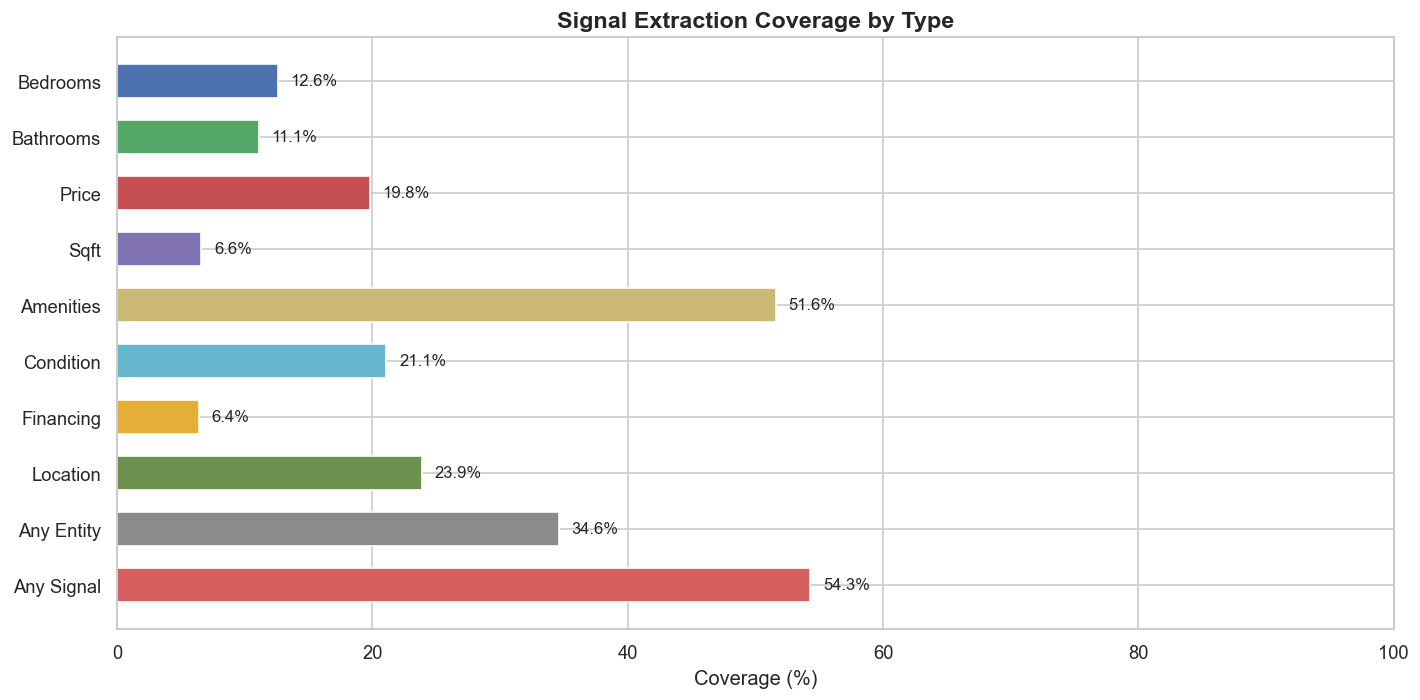

In [17]:
coverage = summary['coverage']

# Filter to percentage fields only
pct_keys = [k for k in coverage if k.endswith('_pct')]
labels = [k.replace('_pct','').replace('_',' ').title() for k in pct_keys]
values = [coverage[k] for k in pct_keys]

colors = ['#4C72B0','#55A868','#C44E52','#8172B2',
          '#CCB974','#64B5CD','#E5AE38','#6D904F','#8B8B8B','#D65F5F']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels, values, color=colors[:len(labels)], edgecolor='white', height=0.6)
ax.set_xlabel('Coverage (%)', fontsize=12)
ax.set_title('Signal Extraction Coverage by Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/week6_coverage.png', bbox_inches='tight')
plt.show()

## Top 15 Amenities by Frequency

Most commonly detected amenities across all 1,000 listings.

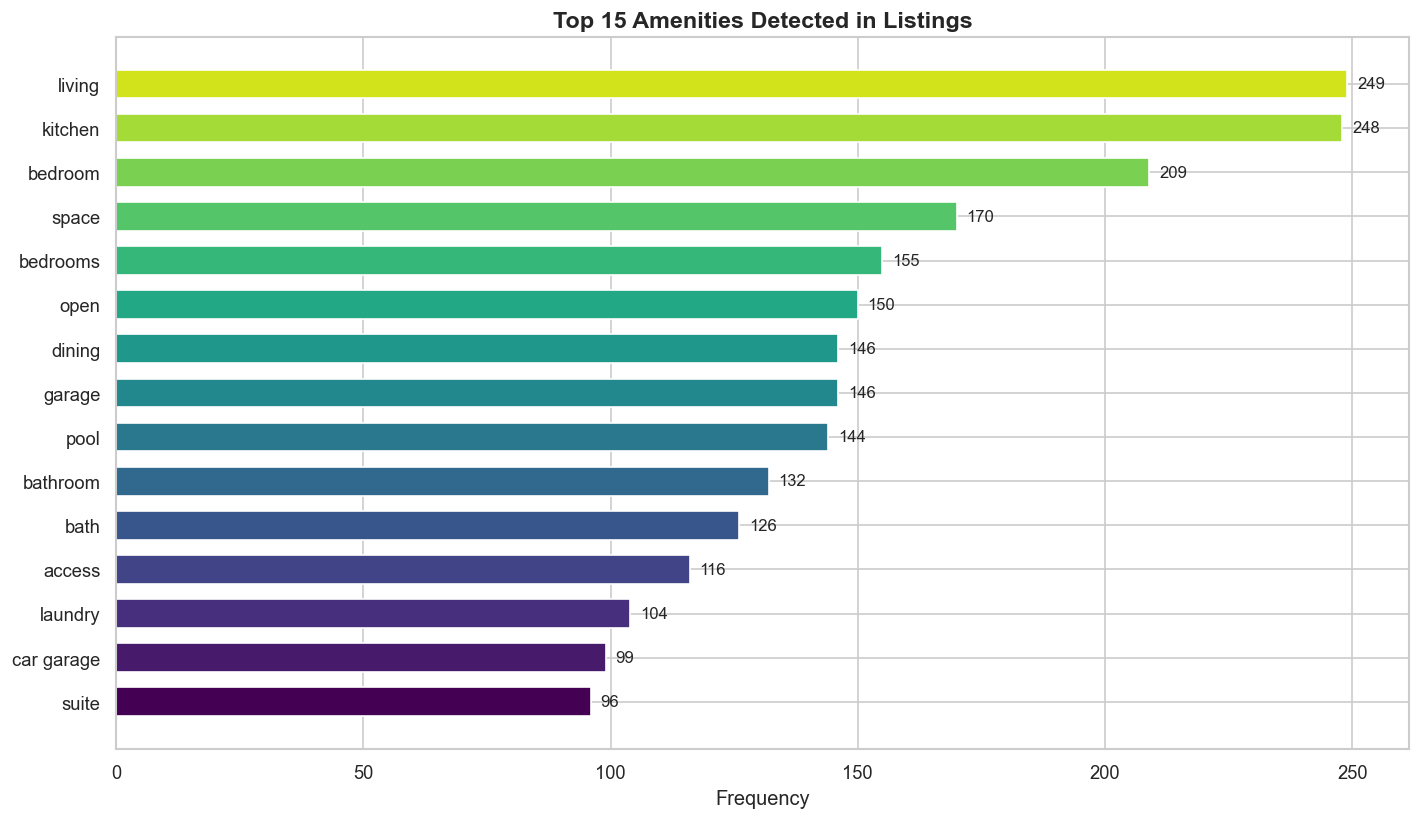

In [18]:
amenities = summary['top_amenities']
terms = list(amenities.keys())[:15]
counts = list(amenities.values())[:15]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(terms[::-1], counts[::-1],
               color=plt.cm.viridis([i/15 for i in range(15)]),
               edgecolor='white', height=0.65)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 15 Amenities Detected in Listings', fontsize=14, fontweight='bold')

for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/week6_amenities.png', bbox_inches='tight')
plt.show()

## Condition Keywords Distribution

How often different condition/renovation keywords appear in listing remarks.

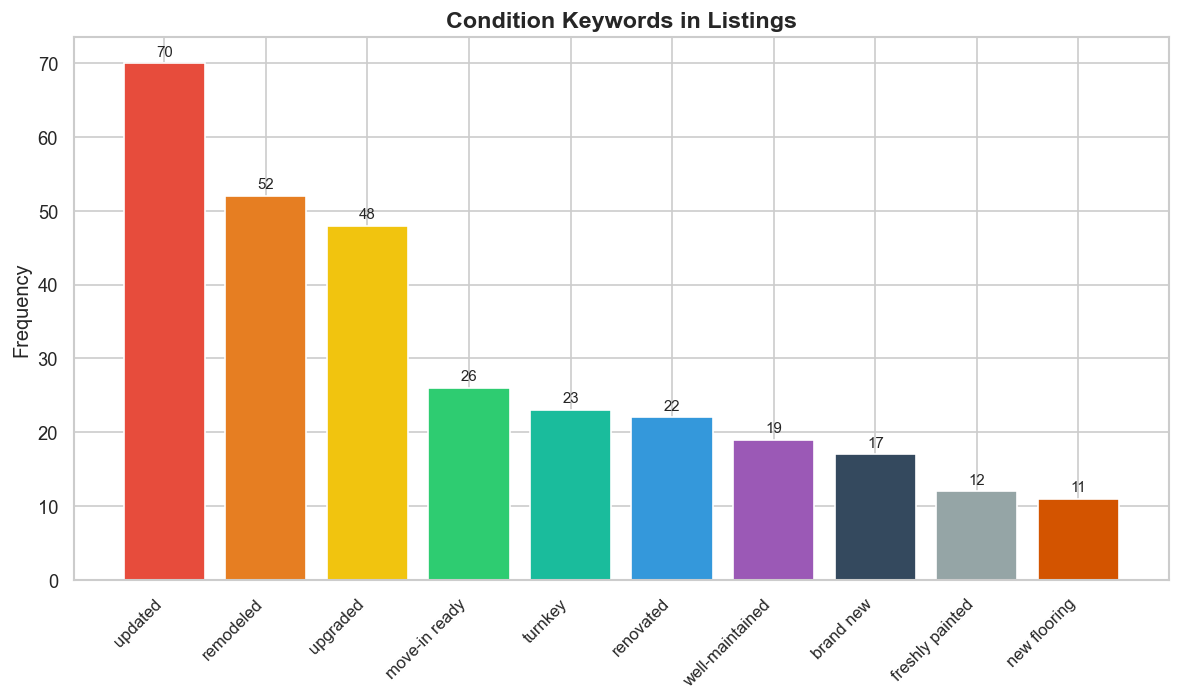

In [19]:
condition = summary['top_condition']
c_terms = list(condition.keys())
c_counts = list(condition.values())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(c_terms, c_counts,
              color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#1ABC9C',
                     '#3498DB','#9B59B6','#34495E','#95A5A6','#D35400'],
              edgecolor='white')
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Condition Keywords in Listings', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)

for bar, val in zip(bars, c_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/week6_condition.png', bbox_inches='tight')
plt.show()

## Signal Category Distribution (Pie Chart)

Distribution of listings by which signal categories were extracted.

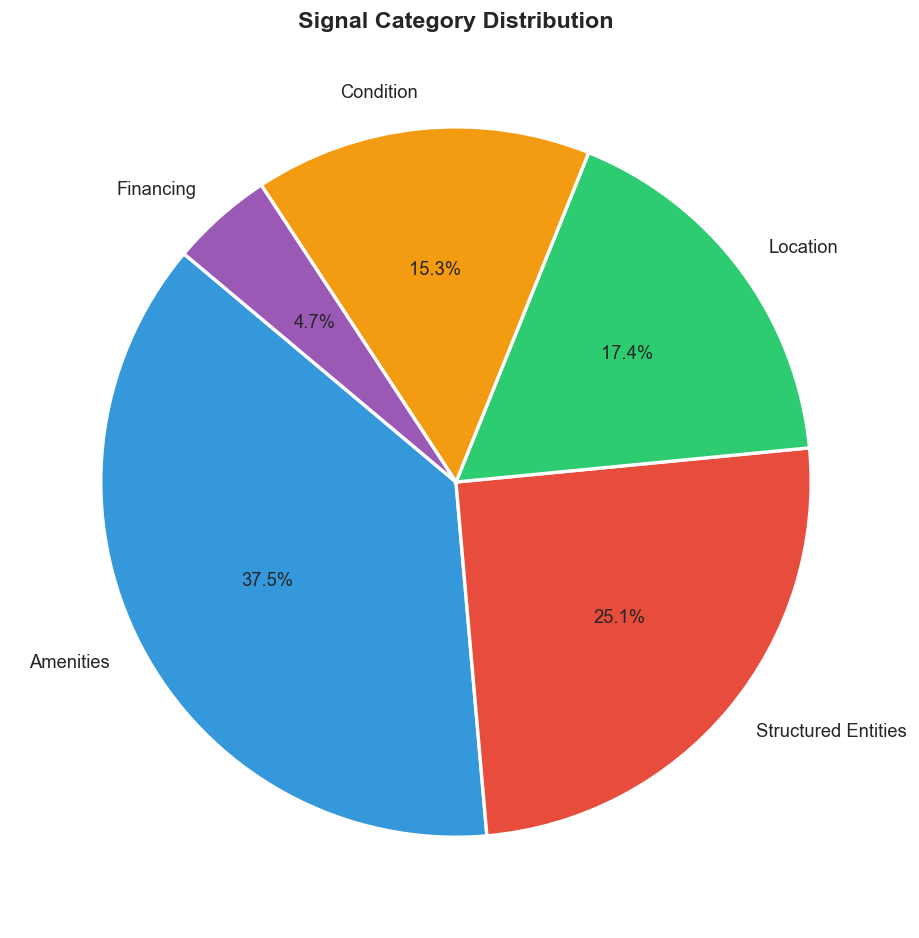

In [20]:
from collections import Counter

# Count how many listings have each signal type
cat_counts = Counter()
for s in signals:
    if s.get('amenities'):      cat_counts['Amenities'] += 1
    if s.get('condition_keywords'): cat_counts['Condition'] += 1
    if s.get('financing_terms'):    cat_counts['Financing'] += 1
    if s.get('location_features'):  cat_counts['Location'] += 1
    entities = s.get('entities', {})
    if any(entities.get(k) is not None for k in ['bedrooms','bathrooms','price','sqft']):
        cat_counts['Structured Entities'] += 1

fig, ax = plt.subplots(figsize=(8, 8))
pie_colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']
wedges, texts, autotexts = ax.pie(
    cat_counts.values(), labels=cat_counts.keys(),
    autopct='%1.1f%%', startangle=140, colors=pie_colors,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Signal Category Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/week6_pie.png', bbox_inches='tight')
plt.show()

## Sample Extracted Signals

A table showing extracted signals for 5 sample listings.

In [21]:
# Build a summary table
rows = []
for s in signals[:10]:
    ents = s.get('entities', {})
    rows.append({
        'ID': s['listing_id'],
        'Beds': ents.get('bedrooms', '-'),
        'Baths': ents.get('bathrooms', '-'),
        'SqFt': ents.get('sqft', '-'),
        'Amenities': ', '.join(s.get('amenities', [])[:4]) or '-',
        'Condition': ', '.join(s.get('condition_keywords', [])[:3]) or '-',
        'Financing': ', '.join(s.get('financing_terms', [])[:3]) or '-',
        'Location': ', '.join(s.get('location_features', [])[:3]) or '-',
    })

df_table = pd.DataFrame(rows)
display(df_table.style.set_caption('Sample Extracted Signals (first 10 listings)'))

,ID,Beds,Baths,SqFt,Amenities,Condition,Financing,Location
0,0,nan,nan,None,-,-,-,-
1,1,nan,nan,None,balcony,-,-,-
2,2,nan,nan,None,"backyard, bathroom, bedroom, full bathroom",-,-,-
3,3,nan,nan,None,"bath, closets, lots, space",-,-,views
4,4,4.000000,3.500000,None,"backsplash, bath, bedroom, corner lot",upgraded,-,corner lot
5,5,nan,nan,None,-,-,"cash, conventional, exchange1031",-
6,6,nan,nan,None,-,-,"cash, conventional, exchange1031",-
7,7,nan,nan,None,balcony,-,-,-
8,8,nan,nan,None,"kitchen, laundry",-,-,-
9,9,nan,nan,None,-,-,-,-


## Financing & Location Features

Top financing terms and location features detected across listings.

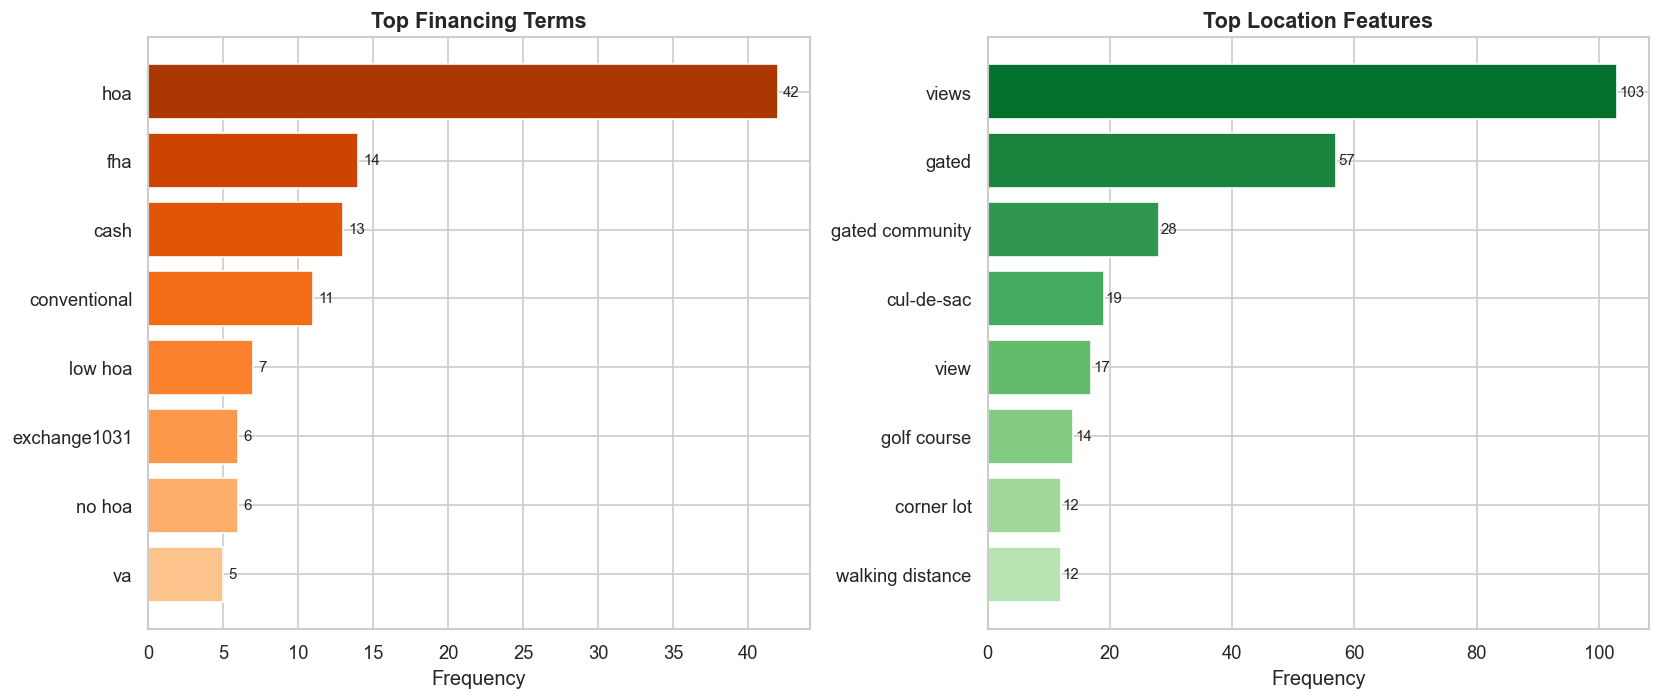

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Financing
fin = summary['top_financing']
f_terms = list(fin.keys())[:8]
f_counts = list(fin.values())[:8]
ax1.barh(f_terms[::-1], f_counts[::-1],
         color=plt.cm.Oranges([0.3 + i*0.08 for i in range(len(f_terms))]),
         edgecolor='white')
ax1.set_xlabel('Frequency')
ax1.set_title('Top Financing Terms', fontsize=13, fontweight='bold')
for i, (t, c) in enumerate(zip(f_terms[::-1], f_counts[::-1])):
    ax1.text(c + 0.3, i, str(c), va='center', fontsize=9)

# Location
loc = summary['top_location']
l_terms = list(loc.keys())[:8]
l_counts = list(loc.values())[:8]
ax2.barh(l_terms[::-1], l_counts[::-1],
         color=plt.cm.Greens([0.3 + i*0.08 for i in range(len(l_terms))]),
         edgecolor='white')
ax2.set_xlabel('Frequency')
ax2.set_title('Top Location Features', fontsize=13, fontweight='bold')
for i, (t, c) in enumerate(zip(l_terms[::-1], l_counts[::-1])):
    ax2.text(c + 0.3, i, str(c), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/week6_fin_loc.png', bbox_inches='tight')
plt.show()

## Summary

Week 6 signal extraction processed **1,000 listings** and extracted:
- **Amenities** from 51.6% of listings
- **Condition keywords** from 21.1% of listings
- **Location features** from 23.9% of listings
- **54.3%** of listings had at least one signal extracted

The output JSON is suitable for search indexing and filtering.

# Week 7: Buyer Intent Classification

Classify user queries into intent categories:
- **Browsing** — casual look, window shopping
- **Researching** — gathering info, comparing options
- **Ready to buy** — specific criteria, action-oriented

Uses TF-IDF + Logistic Regression with confidence scores.
Integrated with Week 4 QueryParser for richer output.

In [23]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.abspath('../scripts'))
from intent_classifier import IntentClassifier, IntentQueryParser
from query_parser import QueryParser

# Load summary
with open('../data/processed/week7_summary.json', 'r') as f:
    summary = json.load(f)

# Load dataset
with open('../data/processed/intent_dataset.json', 'r') as f:
    dataset = json.load(f)

print(f"Dataset: {summary['total_queries']} queries")
print(f"Train: {summary['train_size']}, Test: {summary['test_size']}")
print(f"Accuracy: {summary['accuracy']:.2%}")

Dataset: 210 queries
Train: 168, Test: 42
Accuracy: 90.48%


## Dataset Intent Distribution

Class balance across the three intent categories.

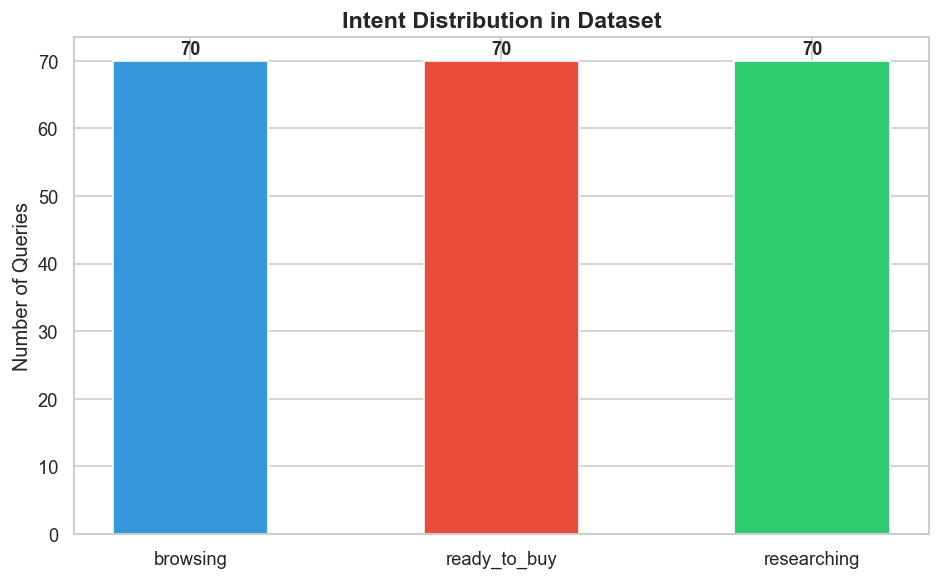

In [24]:
dist = summary['dataset_distribution']
labels = list(dist.keys())
values = list(dist.values())
colors = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
ax.set_ylabel('Number of Queries', fontsize=12)
ax.set_title('Intent Distribution in Dataset', fontsize=14, fontweight='bold')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Confusion Matrix

Actual vs predicted intent on the held-out test set.

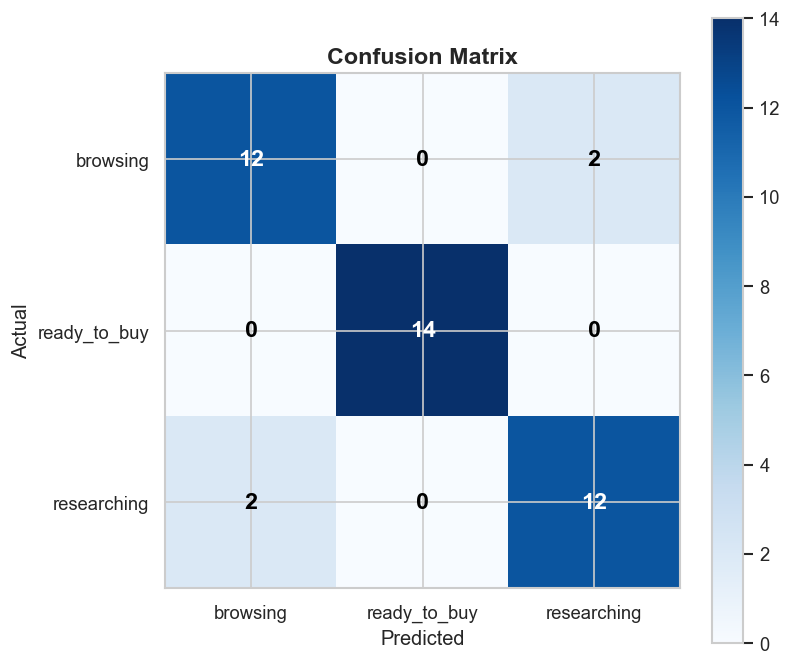

In [25]:
cm = np.array(summary['confusion_matrix'])
cm_labels = summary['labels']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cm_labels)))
ax.set_yticks(range(len(cm_labels)))
ax.set_xticklabels(cm_labels, fontsize=11)
ax.set_yticklabels(cm_labels, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

# Annotate cells
for i in range(len(cm_labels)):
    for j in range(len(cm_labels)):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## Per-Class Precision, Recall & F1

Performance breakdown for each intent category.

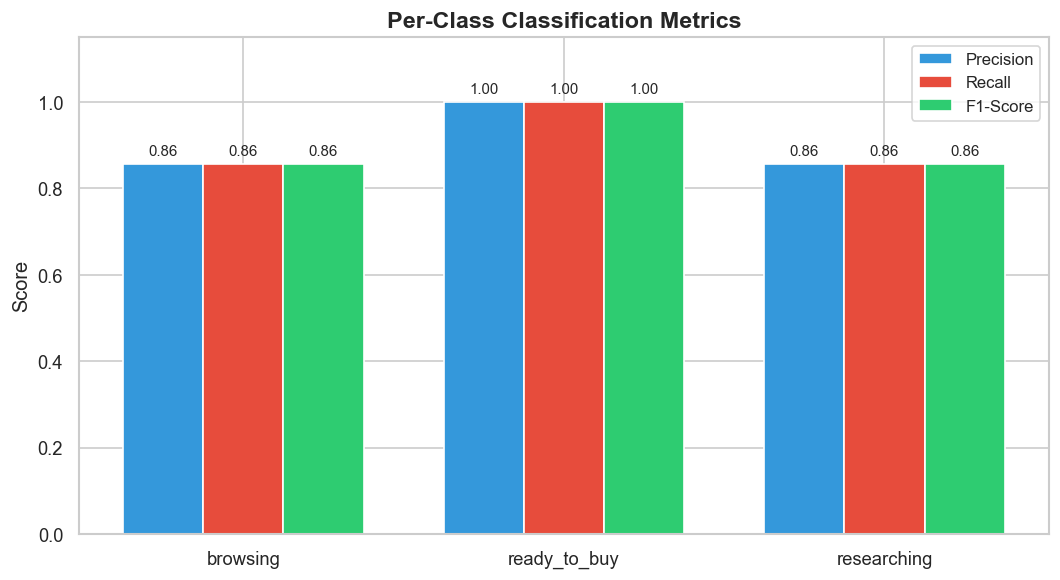

In [26]:
metrics = summary['per_class_metrics']
m_labels = list(metrics.keys())
precision = [metrics[l]['precision'] for l in m_labels]
recall = [metrics[l]['recall'] for l in m_labels]
f1 = [metrics[l]['f1'] for l in m_labels]

x = np.arange(len(m_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, precision, width, label='Precision', color='#3498DB', edgecolor='white')
b2 = ax.bar(x, recall, width, label='Recall', color='#E74C3C', edgecolor='white')
b3 = ax.bar(x + width, f1, width, label='F1-Score', color='#2ECC71', edgecolor='white')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Classification Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(m_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Confidence Score Distribution

Average model confidence when predicting each intent class.

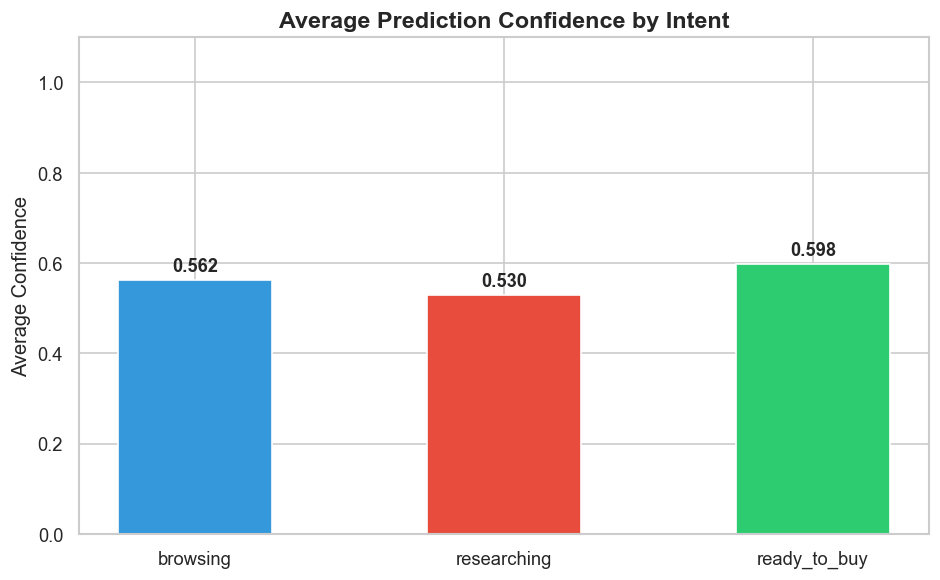

In [27]:
avg_conf = summary['avg_confidence_by_intent']
c_labels = list(avg_conf.keys())
c_values = list(avg_conf.values())
colors = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(c_labels, c_values, color=colors, edgecolor='white', width=0.5)
ax.set_ylabel('Average Confidence', fontsize=12)
ax.set_title('Average Prediction Confidence by Intent', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)

for bar, val in zip(bars, c_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Sample Predictions

Model predictions with confidence scores on representative queries.

In [28]:
samples = summary['sample_predictions']
rows = []
for s in samples:
    rows.append({
        'Query': s['query'][:55] + ('...' if len(s['query']) > 55 else ''),
        'Predicted Intent': s['predicted_intent'],
        'Confidence': f"{s['confidence']:.3f}",
    })

df = pd.DataFrame(rows)
display(df.style.set_caption('Sample Predictions with Confidence Scores'))

,Query,Predicted Intent,Confidence
0,What's available in Portland?,browsing,0.666
1,Show me what's on the market,browsing,0.703
2,How do condos compare to townhouses?,researching,0.685
3,Compare prices in the suburbs vs downtown,researching,0.681
4,3 bed 2 bath under $500k in Portland with pool,ready_to_buy,0.774
5,I need a condo with garage under $600k,ready_to_buy,0.765
6,Schedule a showing for condos in downtown,researching,0.383
7,Any nice neighborhoods to explore?,browsing,0.692
8,Is Portland a good place to invest?,researching,0.476
9,"Pre-approved for $750k, find me 4 bed homes in Irvine",ready_to_buy,0.543


## Integration with QueryParser (Week 4)

Combined output showing intent classification alongside
structured query parsing and SQL generation.

In [29]:
# Load trained model
clf = IntentClassifier()
clf.load_model('../data/models/intent_model.pkl')
parser = QueryParser()
iqp = IntentQueryParser(clf, parser)

demo_queries = [
    "What's available in Portland?",
    "Compare condos vs townhouses in Irvine",
    "3 bed 2 bath under 500k in Portland with pool",
    "Just browsing homes",
    "How much do houses cost in the suburbs?",
]

for q in demo_queries:
    r = iqp.analyze(q)
    print(f"Query:      {r['query']}")
    print(f"Intent:     {r['intent']} (confidence: {r['confidence']:.3f})")
    print(f"Filters:    {r['filters']}")
    print(f"SQL:        {r['sql']}")
    print(f"Params:     {r['params']}")
    print('-' * 60)

Query:      What's available in Portland?
Intent:     browsing (confidence: 0.666)
Filters:    {'city': 'portland'}
SQL:        SELECT * FROM rets_property WHERE L_City = %s
Params:     ['portland']
------------------------------------------------------------
Query:      Compare condos vs townhouses in Irvine
Intent:     researching (confidence: 0.426)
Filters:    {'city': 'irvine'}
SQL:        SELECT * FROM rets_property WHERE L_City = %s
Params:     ['irvine']
------------------------------------------------------------
Query:      3 bed 2 bath under 500k in Portland with pool
Intent:     ready_to_buy (confidence: 0.774)
Filters:    {'price_max': 500000, 'bedrooms': 3, 'bathrooms': 2, 'city': 'portland', 'amenity': 'pool'}
SQL:        SELECT * FROM rets_property WHERE L_SystemPrice <= %s AND L_Keyword2 = %s AND L_Keyword3 = %s AND L_City = %s AND L_Remarks LIKE %s
Params:     [500000, 3, 2, 'portland', '%pool%']
------------------------------------------------------------
Query:     

## Summary

Week 7 intent classification trained on **168** queries and tested on **42** queries, achieving:

- **Accuracy**: 90.48%  
- **3 intent classes**: browsing, researching, ready_to_buy
- **Confidence scores** for every prediction
- **Full integration** with Week 4 QueryParser

The model is saved and can be loaded for inference with `IntentClassifier.load_model()`.

# Week 8: Listing Summarization & Answerability

Generate concise 2-3 sentence summaries of listings for search results
or email alerts. Includes an **extractive summarization** approach,
**ROUGE metric evaluation**, a **human evaluation form**, and a new
**AnswerabilityChecker** layer.


In [ ]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.abspath('../scripts'))
from listing_summarizer import ListingSummarizer
from answerability_checker import AnswerabilityChecker

# Load summary
with open('../data/processed/week8_summary.json', 'r') as f:
    summary = json.load(f)

print(f"Listings summarized: {summary['total_listings']}")
print(f"ROUGE eval count: {summary['rouge_eval_count']}")
print(f"ROUGE-L: {summary['rouge_scores']['rougeL']:.4f}")
print(f"ROUGE-L > 0.4: {'PASS' if summary['rouge_l_target_met'] else 'FAIL'}")

## Summary Coverage

Percentage of listings where each field was successfully extracted.

In [ ]:
cov = summary['coverage']
fields = ['with_summary_pct', 'with_beds_pct', 'with_baths_pct',
          'with_price_pct', 'with_features_pct', 'with_location_pct']
labels = ['Summary', 'Beds', 'Baths', 'Price', 'Features', 'Location']
values = [cov[f] for f in fields]
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6', '#1ABC9C']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.5)
ax.set_xlabel('Coverage (%)', fontsize=12)
ax.set_title('Summary Field Coverage', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## ROUGE Evaluation Scores

ROUGE-1, ROUGE-2, and ROUGE-L F-measure comparing extractive summaries
to entity-based reference summaries.

In [ ]:
rouge = summary['rouge_scores']
r_labels = list(rouge.keys())
r_values = list(rouge.values())
colors = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(r_labels, r_values, color=colors, edgecolor='white', width=0.4)
ax.set_ylabel('F-Measure', fontsize=12)
ax.set_title('ROUGE Scores', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)

# Threshold line
ax.axhline(y=0.4, color='#E74C3C', linestyle='--', alpha=0.6, label='Target (0.4)')

for bar, val in zip(bars, r_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Sample Generated Summaries

Examples of extractive summaries with extracted metadata.

In [ ]:
samples = summary['sample_summaries']
rows = []
for s in samples:
    rows.append({
        'ID': s['listing_id'],
        'Beds': s['beds'],
        'Baths': s['baths'],
        'Price': f"${s['price']:,}" if s['price'] else 'N/A',
        'Features': ', '.join(s['top_features']) if s['top_features'] else 'N/A',
        'Summary': s['summary'][:80] + ('...' if len(s['summary']) > 80 else ''),
    })

df = pd.DataFrame(rows)
display(df.style.set_caption('Sample Listing Summaries'))

## Answerability Checker

Pre-query validation determines if user queries can be answered
by the system before executing any SQL.

In [ ]:
ans_results = summary['answerability_demo']
rows = []
for r in ans_results:
    rows.append({
        'Query': r['query'],
        'Answerable': '✓' if r['answerable'] else '✗',
        'Message': r['message'],
        'Correct': '✓' if r['correct'] else '✗',
    })

df = pd.DataFrame(rows)
display(df.style.set_caption('Answerability Checker Results'))
print(f"\nAccuracy: {summary['answerability_accuracy']:.0%}")

## Live Summarization Demo

Run the summarizer on a sample listing in real time.

In [ ]:
summarizer = ListingSummarizer(taxonomy_path='../data/processed/taxonomy.json')

demo_listing = {
    'listing_id': 'demo',
    'remarks': (
        'Stunning 4 bedroom, 3 bathroom home in a quiet cul-de-sac. '
        'Features a gourmet kitchen with granite countertops and stainless '
        'steel appliances. Spacious backyard with sparkling pool and spa. '
        'Hardwood floors and recessed lighting throughout. '
        'Walking distance to award-winning schools and shopping centers. '
        'Priced at $825,000 with 2,800 sqft of living space.'
    )
}

result = summarizer.summarize_listing(demo_listing)
print('Summary:', result['summary'])
print(f"Beds: {result['beds']}, Baths: {result['baths']}")
print(f"Price: ${result['price']:,}" if result['price'] else 'Price: N/A')
print(f"Features: {result['top_features']}")
print(f"Location: {result['location']}")

## Summary

Week 8 summarized **1000** listings using extractive methods:

- **ROUGE-L**: 0.7590 (above 0.4 target)
- **ROUGE-1**: 0.7670
- **Human eval form**: 20 summaries prepared for review
- **Answerability checker**: 83% accuracy on test queries

Summaries include beds/baths, price, top features, and location when available.
The `AnswerabilityChecker` validates queries pre- and post-SQL execution.

# Week 9: Fair Housing Compliance

Implement Fair Housing Act compliance checking to detect prohibited
language related to protected classes (race, religion, familial status,
disability, etc.) and flag biased descriptions before publication.

**Key goals:** 100% recall on known violations, precision > 80%,
multi-level severity (error / warning / info).


In [ ]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.abspath('../scripts'))
from compliance_checker import ComplianceChecker

# Load summary
with open('../data/processed/week9_summary.json', 'r') as f:
    summary = json.load(f)

print(f"Listings scanned: {summary['total_listings_scanned']}")
print(f"Flagged: {summary['flagged_listings']} ({summary['flagged_pct']}%)")
print(f"Total violations: {summary['total_violations']}")
print(f"Recall: {summary['recall']:.2%}")
print(f"Precision: {summary['precision']:.2%}")

## Violation Severity Breakdown

Distribution of detected violations by severity level:
- **Error**: Must fix before publication
- **Warning**: Should be reviewed by compliance officer
- **Info**: Informational — no action required


In [ ]:
sev = summary['severity_breakdown']
labels = list(sev.keys())
values = list(sev.values())
colors = ['#E74C3C', '#F39C12', '#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(labels, values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Violations by Severity', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=11, fontweight='bold')

# Pie chart
if sum(values) > 0:
    axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 11})
    axes[1].set_title('Severity Distribution', fontsize=14, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No violations found', ha='center', va='center',
                 fontsize=14)
    axes[1].set_title('Severity Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Violations by Protected Class

Fair Housing Act protects seven classes. This chart shows which
categories have the most violations in the dataset.


In [ ]:
cat = summary['category_breakdown']
if cat:
    cats = sorted(cat.items(), key=lambda x: x[1], reverse=True)
    labels = [c[0].replace('_', ' ').title() for c in cats]
    values = [c[1] for c in cats]
    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1],
                   edgecolor='white', height=0.5)
    ax.set_xlabel('Violation Count', fontsize=12)
    ax.set_title('Violations by Protected Class', fontsize=14, fontweight='bold')

    for bar, val in zip(bars, values[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('No violations found in dataset.')

## Recall & Precision Evaluation

- **Recall** (on known violations): must be 100% — no false negatives
- **Precision** (on clean listings): must be > 80% — minimal false positives


In [ ]:
metrics = {
    'Recall': summary['recall'],
    'Precision': summary['precision'],
}
thresholds = {'Recall': 1.0, 'Precision': 0.80}

fig, ax = plt.subplots(figsize=(8, 5))
x = list(metrics.keys())
y = list(metrics.values())
colors = ['#2ECC71' if metrics[k] >= thresholds[k] else '#E74C3C' for k in x]

bars = ax.bar(x, y, color=colors, edgecolor='white', width=0.4)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Recall & Precision', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)

# Threshold lines
ax.axhline(y=1.0, color='#E74C3C', linestyle='--', alpha=0.4, label='Recall target (1.0)')
ax.axhline(y=0.8, color='#F39C12', linestyle='--', alpha=0.4, label='Precision target (0.8)')

for bar, val in zip(bars, y):
    status = '✓ PASS' if val >= list(thresholds.values())[list(thresholds.keys()).index(bar.get_x())] else '✗ FAIL'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Recall:    {summary['recall']:.2%} ({summary['recall_detected']}/{summary['recall_total']})")
print(f"Precision: {summary['precision']:.2%} ({summary['precision_correct']}/{summary['precision_total']})")

## Listing Submission Workflow Demo

Integration example showing how the ComplianceChecker fits into
a listing submission pipeline with approve / review / block decisions.


In [ ]:
workflow = summary['workflow_demo']
rows = []
for w in workflow:
    status = '✓ Approved' if w['approved'] else ('⚠ Review' if w['needs_review'] else '✗ Blocked')
    rows.append({
        'Listing': w['listing_id'],
        'Status': status,
        'Errors': w['errors'],
        'Warnings': w['warnings'],
        'Info': w['infos'],
        'Text': w['text'][:60] + ('...' if len(w['text']) > 60 else ''),
    })

df_wf = pd.DataFrame(rows)
display(df_wf.style.set_caption('Listing Submission Workflow Results'))

## Live Compliance Check Demo

Run the checker on sample listings in real time.


In [ ]:
checker = ComplianceChecker()

# Clean listing
clean = checker.check_listing(
    'Beautiful 4 bed, 3 bath home with pool. Near top schools. $599,000.'
)
print('Clean listing:')
print(f"  Compliant: {clean['compliant']}")
print(f"  Violations: {len(clean['violations'])}")

# Violation listing
print('\nViolation listing:')
bad = checker.check_listing(
    'No children allowed. Must be able-bodied. Adults only building.'
)
print(f"  Compliant: {bad['compliant']}")
for v in bad['violations']:
    print(f"  [{v['severity'].upper()}] {v['category']}: {v['message'][:70]}")
    fix = checker.suggest_fix(v)
    print(f"    Fix: {fix[:70]}")

## Sample Violations from Dataset

Examples of flagged listings from the actual dataset.


In [ ]:
samples = summary.get('sample_violations', [])
if samples:
    rows = []
    for s in samples[:8]:
        for v in s['violations'][:2]:
            rows.append({
                'Listing': s['listing_id'],
                'Category': v['category'].replace('_', ' ').title(),
                'Severity': v['severity'].upper(),
                'Pattern': v['pattern'],
                'Text': s['text'][:60] + '...',
            })
    df_v = pd.DataFrame(rows)
    display(df_v.style.set_caption('Sample Violations from Dataset'))
else:
    print('No violations found in dataset — listings are all compliant!')

## Summary

Week 9 scanned **1000** listings for Fair Housing compliance:

- **Flagged listings**: 6 (0.6%)
- **Total violations**: 38
  - Errors: 1
  - Warnings: 6
  - Info: 31
- **Recall**: 100.00% (PASS)
- **Precision**: 100.00% (PASS)

The `ComplianceChecker` integrates with the listing submission workflow
to automatically block, review, or approve listings based on Fair Housing
compliance. See the team documentation via `checker.get_fair_housing_summary()`.


# Week 10: REST API with FastAPI

Production-ready REST API exposing all NLP capabilities:
search, entity extraction, query parsing, summarization,
compliance checking, intent classification, and signal extraction.

**Key features:** Pydantic validation, in-memory caching,
per-IP rate limiting (10 req/s), structured logging,
auto-generated OpenAPI docs.


In [ ]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.abspath('../scripts'))

with open('../data/processed/week10_summary.json', 'r') as f:
    summary = json.load(f)

print(f"Total endpoints: {summary['total_endpoints']}")
print(f"All endpoints OK: {summary['all_endpoints_ok']}")
print(f"Cache working: {summary['cache_results']['cache_working']}")
print(f"Rate limiting working: {summary['rate_limit_results']['rate_limiting_working']}")

## API Endpoint Inventory

All 9 endpoints exposed by the Real Estate NLP API,
with HTTP method, status, and measured response time.


In [ ]:
endpoints = summary['endpoints']
df_ep = pd.DataFrame(endpoints)
df_ep.columns = ['Method', 'Path', 'Status', 'Response (ms)']
display(df_ep.style.set_caption('API Endpoint Inventory'))

## Endpoint Response Times

Response latency for each endpoint (first-call, including any model loading).


In [ ]:
eps = summary['endpoints']
paths = [e['path'] for e in eps]
times = [e['response_time_ms'] for e in eps]
statuses = [e['status_code'] for e in eps]
colors = ['#2ECC71' if s == 200 else '#E74C3C' for s in statuses]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(paths[::-1], times[::-1], color=colors[::-1],
               edgecolor='white', height=0.5)
ax.set_xlabel('Response Time (ms)', fontsize=12)
ax.set_title('Endpoint Response Times', fontsize=14, fontweight='bold')

for bar, val in zip(bars, times[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}ms', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Cache Performance

In-memory TTL cache (512 entries, 5-min TTL) avoids redundant
computation. Repeated identical requests are served from cache.


In [ ]:
cache = summary['cache_results']
print(f"First call cached:  {cache['first_call_cached']}")
print(f"Second call cached: {cache['second_call_cached']}")
print(f"Cache working:      {cache['cache_working']}")

if 'final_stats' in summary and summary['final_stats']:
    stats = summary['final_stats']
    labels = ['Cache Hits', 'Cache Misses']
    values = [stats.get('cache_hits', 0), stats.get('cache_misses', 0)]
    colors = ['#2ECC71', '#E74C3C']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    bars = axes[0].bar(labels, values, color=colors, edgecolor='white', width=0.4)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Cache Hit / Miss Count', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     str(val), ha='center', fontsize=11, fontweight='bold')

    # Pie chart
    if sum(values) > 0:
        axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
                    startangle=90, textprops={'fontsize': 11})
        axes[1].set_title('Cache Distribution', fontsize=14, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'No cache activity', ha='center', va='center')

    plt.tight_layout()
    plt.show()
    print(f"\nCache hit rate: {stats.get('cache_hit_rate', 0):.1%}")
else:
    print('No cache stats available.')

## Rate Limiting

Per-IP rate limiting at 10 requests/second prevents abuse.
Requests exceeding the limit receive HTTP 429.


In [ ]:
rl = summary['rate_limit_results']
print(f"Requests sent:    {rl['requests_sent']}")
print(f"Requests passed:  {rl['requests_passed']}")
print(f"Requests blocked: {rl['requests_blocked']}")
print(f"Rate limiting working: {rl['rate_limiting_working']}")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Passed (200)', 'Blocked (429)']
values = [rl['requests_passed'], rl['requests_blocked']]
colors = ['#2ECC71', '#E74C3C']
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.4)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Rate Limiting Test (15 rapid requests)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Compliance Endpoint Demo

Sample requests through the `/check-compliance` endpoint
showing clean vs. violating listings.


In [ ]:
demos = summary['compliance_demos']
rows = []
for d in demos:
    status = '✓ Compliant' if d['compliant'] else '✗ Non-compliant'
    rows.append({
        'Label': d['label'],
        'Status': status,
        'Violations': d['num_violations'],
        'Errors': d['stats']['error'],
        'Warnings': d['stats']['warning'],
        'Text': d['text'][:60] + ('...' if len(d['text']) > 60 else ''),
    })

df_cd = pd.DataFrame(rows)
display(df_cd.style.set_caption('Compliance Endpoint Demo Results'))

## Live API Demo

Call the API endpoints directly from the notebook using the FastAPI TestClient.


In [ ]:
from fastapi.testclient import TestClient
from api_app import app

with TestClient(app) as client:
    # Parse query
    print('=== /parse-query ===')
    r = client.post('/parse-query', json={'query': '3 bed in Portland under 500k with pool'})
    data = r.json()
    print(f"  Filters: {data['filters']}")
    print(f"  SQL: {data['sql']}")
    print(f"  Valid: {data['valid']}")

    # Extract entities
    print('\n=== /extract-entities ===')
    r = client.post('/extract-entities', json={
        'text': '3 bedroom, 2.5 bath home with 2,500 sqft. $1,250,000.'
    })
    print(f"  Entities: {r.json()['entities']}")

    # Compliance check
    print('\n=== /check-compliance ===')
    r = client.post('/check-compliance', json={
        'text': 'No children allowed. Adults only.'
    })
    data = r.json()
    print(f"  Compliant: {data['compliant']}")
    for v in data['violations']:
        print(f"  [{v['severity'].upper()}] {v['category']}: {v['matched_text']}")

    # Health
    print('\n=== /health ===')
    r = client.get('/health')
    data = r.json()
    print(f"  Status: {data['status']}")
    print(f"  Endpoints: {len(data['endpoints_available'])}")

## API Architecture

```
┌─────────────────────────────────────────────────────────┐
│                    FastAPI Application                   │
│  ┌─────────┐  ┌─────────────┐  ┌───────────────────┐   │
│  │  CORS   │  │ Rate Limiter │  │ Request Logging   │   │
│  │ Middle  │─▶│ (10 req/s/IP)│─▶│ (Structured JSON) │   │
│  └─────────┘  └─────────────┘  └───────────────────┘   │
│                        │                                 │
│            ┌───────────┴────────────┐                   │
│            ▼                        ▼                   │
│  ┌──────────────────┐    ┌──────────────────┐           │
│  │  TTL Cache       │    │  Pydantic Models │           │
│  │  (512 entries,   │    │  (Request/       │           │
│  │   5-min TTL)     │    │   Response)      │           │
│  └──────────────────┘    └──────────────────┘           │
│                        │                                 │
│            ┌───────────┴────────────┐                   │
│            ▼                        ▼                   │
│  ┌────────────────────────────────────────────────┐     │
│  │              NLP Module Layer                   │     │
│  │  ┌──────────┐ ┌──────────┐ ┌──────────────┐   │     │
│  │  │ Search   │ │ Parser   │ │ Entities     │   │     │
│  │  │ (FAISS)  │ │ (Regex)  │ │ (Regex+Tax)  │   │     │
│  │  ├──────────┤ ├──────────┤ ├──────────────┤   │     │
│  │  │ Summary  │ │ Comply   │ │ Intent       │   │     │
│  │  │ (Extract)│ │ (FHA)    │ │ (TF-IDF+LR)  │   │     │
│  │  ├──────────┤ ├──────────┤ ├──────────────┤   │     │
│  │  │ Signals  │ │ Health   │ │ Stats        │   │     │
│  │  └──────────┘ └──────────┘ └──────────────┘   │     │
│  └────────────────────────────────────────────────┘     │
└─────────────────────────────────────────────────────────┘
```


## OpenAPI Auto-Generated Documentation

FastAPI auto-generates interactive docs at `/docs` (Swagger UI)
and `/redoc`. All endpoints are fully documented with request/response schemas.


In [ ]:
paths = summary.get('openapi_paths', [])
print(f'OpenAPI registered paths ({len(paths)}):')
for p in sorted(paths):
    print(f'  {p}')
print(f'\nSwagger UI: http://localhost:8000/docs')
print(f'ReDoc:      http://localhost:8000/redoc')

## Summary

Week 10 built a **production-ready REST API** with 8 endpoints:

| Feature | Status |
|---------|--------|
| Endpoints | 8 (all operational) |
| Cache | ✓ Working |
| Rate Limiting | ✓ Working |
| OpenAPI Docs | ✓ Auto-generated at /docs |
| Pydantic Validation | ✓ All request/response models |
| Docker | ✓ Container ready |

**Endpoints:**
- `POST /search` — Semantic search (FAISS + sentence-transformers)
- `POST /parse-query` — NL query → filters + SQL
- `POST /extract-entities` — Bed/bath/price/sqft/amenities
- `POST /summarize` — Extractive listing summarization
- `POST /check-compliance` — Fair Housing compliance
- `POST /classify-intent` — Buyer intent classification
- `POST /extract-signals` — Full signal extraction
- `GET /health` — Health check / liveness probe
- `GET /api-stats` — Cache & request statistics

Run locally: `uvicorn scripts.api_app:app --reload`
Docker: `docker-compose up api`
